### Debugginh Bayesian_DRO_continuous

The set-up is the following:

- We run `Bayesian_DRO_continuous.py` which calls the `main_Bayesian_DRO` function; we set the option to `lse=False` which is meant to reproduce the script given to us by the authors. 
- For each replication, we run function `main_Bayesian_DRO` in parallel using the joblib Parallel class. We did this to speed up the computation.
- We did not run `main_DRO`, `main_empirical`, `main_Bayesian_DRO_epsilon1`, `main_Bayesian_DRO_epsilon2`, `main_Bayesian_DRO_epsilon3`, and `main_empirical_DRO_Wasserstein`.
- To match Section 4.1, we set `b = 8`, `my_mean = 10`, and `my_std = 10`.
- For each replication, we save a CSV file containing the solution and cost for each epsilon via a pandas dataframe. Each replication file is called `result_k.csv`, where `k` is the replication number.


Imports

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from bayesian_dro.Bayesian_DRO_continuous import cost, data_generation, EPSILON_SET

/tmp/dcs-tmp.u1604520/ipykernel_1213777/1276062597.py:3: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


Load results from csv files

In [2]:
experiment_dir = Path(f"/dcs/pg23/u1604520/misdro/results_bug_test")
assert experiment_dir.exists()
replication = 200
results_df = pd.concat([pd.read_csv(experiment_dir / f"result_{k}.csv") for k in range(replication)]).set_index(["replication", "epsilon"])
results_df

Unnamed: 0  bayesian_dro_sol  bayesian_dro_cost
replication epsilon                                                 
0           0.001             0             16.88           4.660179
            0.002             1             17.12           5.380179
            0.005             2             17.50           6.520179
            0.010             3             17.96           7.900179
            0.020             4             18.59           9.790179
...                         ...               ...                ...
199         1.000            13             43.87         102.767290
            1.500            14             44.74         105.377290
            2.000            15             48.58         116.897290
            2.500            16             50.00         121.157290
            3.000            17             50.00         121.157290

[3600 rows x 3 columns]

In [3]:
# results_df.loc[(slice(180,None), slice(1.5, None)), :]
results_df.loc[results_df.index.get_level_values("epsilon") == 1.5]

,,Unnamed: 0,bayesian_dro_sol,bayesian_dro_cost
replication,epsilon,,,
0,1.5,14,37.48,66.460179
1,1.5,14,32.78,51.100070
2,1.5,14,32.41,94.257891
3,1.5,14,29.26,72.802570
4,1.5,14,48.74,105.372873
...,...,...,...,...
195,1.5,14,36.45,96.561685
196,1.5,14,40.20,119.072064
197,1.5,14,35.86,63.384627


In [4]:
results_df.loc[results_df.index.get_level_values("epsilon") == 2.0]

,,Unnamed: 0,bayesian_dro_sol,bayesian_dro_cost
replication,epsilon,,,
0,2.0,15,38.08,68.260179
1,2.0,15,35.34,58.780070
2,2.0,15,32.52,94.587891
3,2.0,15,32.90,83.722570
4,2.0,15,50.00,109.152873
...,...,...,...,...
195,2.0,15,37.47,99.621685
196,2.0,15,42.01,124.502064
197,2.0,15,38.64,71.724627


Calculate out-of-sample means and variances

We have concatenated all the CSV files together, then grouped by $\epsilon$.
In each replication $j = 1,\ldots,K$, we are given $N+M$ data points $\xi_1^{(j)}, \ldots, \xi_N^{(j)}, \xi_{N+1}^{(j)}, \ldots, \xi_{N+M}^{(j)}$ where the first $N$ points are the training samples and the last $M$ points are the test sample.
For each $\epsilon$ and each replication $j$, we calculate the out-of-sample mean $\mu^{(j)}(\epsilon)$ and variance $v^{(j)}(\epsilon)$ of the objective function under the $M$ test points:
$$
    \mu^{(j)}(\epsilon) := \mathbb{E}_{\xi \sim \mathbb{P}^\star}~{[G(x^{(j)}(\epsilon), \xi)]} = \frac{1}{M}~\sum_{i=1}^{M}~{G(x^{(j)}(\epsilon), \xi_{i}^{(j)})} \\
    v^{(j)}(\epsilon) := \mathbb{V}_{\xi \sim \mathbb{P}^\star}~{[G(x^{(j)}(\epsilon), \xi)]} = \frac{1}{M-1}~\sum_{i=1}^{M}~{\left(G(x^{(j)}(\epsilon), \xi_{i}^{(j)}) - \mu^{(j)}(\epsilon)\right)^2}
$$
where $\mathbb{P}^\star$ is the true data-generating process (DGP), $K$ is the number of replications, and $x^{(j)}(\epsilon)$ is the solution on replication $j = 1,\ldots,K$.
Over all replications, we then calculate $\hat{\mu}_M(\epsilon)$ and $\hat{v}_M(\epsilon)$, where
$\hat{\mu}_M(\epsilon)$ is the mean-of-the-means,
and $\hat{v}_M(\epsilon)$ is the mean-of-the-variances plus the variance-of-the-means.
$$
    \hat{\mu}_M(\epsilon) :=  \frac{1}{K}~\sum_{j=1}^{K}~{ \mu^{(j)}(\epsilon)}, \\
    \hat{v}_M(\epsilon) := \underbrace{\frac{1}{K}~\sum_{j=1}^{K}~{v^{(j)}(\epsilon)}}_{\text{mean-of-the-variances}} + \underbrace{\frac{1}{K-1}~\sum_{j=1}^{K}~{\left( \mu^{(j)}(\epsilon) - \hat{\mu}_M(\epsilon) \right)^2}}_{\text{variance-of-the-means}}.
$$
Note that setting $M=1$ recovers the out-of-sample mean and variance in the usual way.

In [5]:
# NOTE! the BDRO paper only includes values of epsilon <=0.6
# Here I change this a little bit because we have 1 test point so in-group variances are zero

bdro_results_df = results_df #[results_df.index.get_level_values("epsilon") <= 0.6]

# group by epsilon and replication to get the mean and variance of each replication $j$
bdro_gb = bdro_results_df.groupby(by=["epsilon", "replication"])
bdro_mean_df = bdro_gb.mean()
bdro_var_df = bdro_gb.var()

# get the mean of the means
bdro_mean_of_means = bdro_mean_df.groupby("epsilon")["bayesian_dro_cost"].mean()
# bdro_lse_mean_of_means = bdro_mean_df.groupby("epsilon")["bayesian_dro_lse_cost"].mean()

# get the mean of the variances
#bdro_mean_of_vars = bdro_var_df.groupby("epsilon")["bayesian_dro_cost"].mean()
#bdro_lse_mean_of_vars = bdro_var_df.groupby("epsilon")["bayesian_dro_lse_cost"].mean()

# variance of the means
bdro_var_of_means = bdro_mean_df.groupby("epsilon")["bayesian_dro_cost"].var()
# bdro_lse_var_of_means = bdro_mean_df.groupby("epsilon")["bayesian_dro_lse_cost"].var()

# mean of the variances + variance of the means (as in the BDRO paper)
bdro_paper_var = bdro_var_of_means #bdro_mean_of_vars + bdro_var_of_means
# bdro_lse_paper_var =  bdro_lse_var_of_means #bdro_lse_mean_of_vars + bdro_lse_var_of_means

In [6]:
bdro_mean_of_means

epsilon
0.001     33.186777
0.002     33.212341
0.005     33.217861
0.010     33.239845
0.020     33.452584
0.050     34.187144
0.100     35.935927
0.150     37.628821
0.200     38.992253
0.250     40.724253
0.300     41.712614
0.400     43.686017
0.500     44.906703
1.000     65.927502
1.500     71.922002
2.000     76.073715
2.500    100.827763
3.000    103.833763
Name: bayesian_dro_cost, dtype: float64

In [7]:
bdro_paper_var

epsilon
0.001    817.798835
0.002    794.936563
0.005    751.628665
0.010    711.012906
0.020    663.929115
0.050    594.481170
0.100    568.939874
0.150    565.647540
0.200    572.371261
0.250    573.090156
0.300    599.524965
0.400    601.026539
0.500    639.540567
1.000    755.071911
1.500    821.125871
2.000    882.434838
2.500    700.031767
3.000    667.006315
Name: bayesian_dro_cost, dtype: float64

Plot results

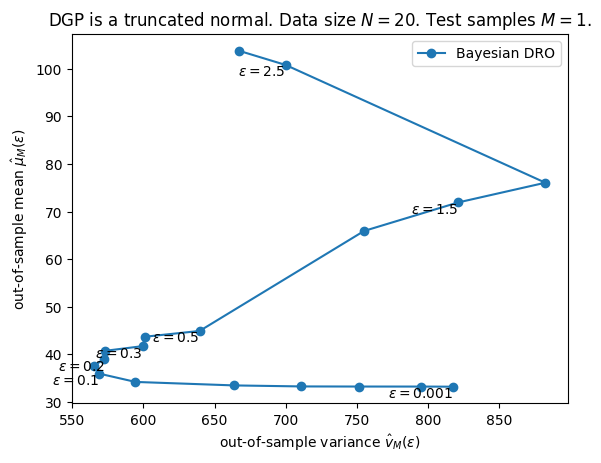

In [8]:
plt.plot(bdro_paper_var, bdro_mean_of_means, marker='o', label="Bayesian DRO")
# plt.plot(bdro_lse_paper_var, bdro_lse_mean_of_means, marker='*', label="Bayesian DRO - LSE")

X_LABEL = "out-of-sample variance $\hat{v}_{M}(\epsilon)$"
Y_LABEL = "out-of-sample mean $\hat{\mu}_{M}(\epsilon)$"
plt.title(f"DGP is a truncated normal. Data size $N = 20$. Test samples $M=1$.")
plt.legend()
plt.xlabel(X_LABEL)
plt.ylabel(Y_LABEL)

for i, epsilon in enumerate(bdro_mean_of_means.index.values):
    if i % 2 == 0 and epsilon >= 0.1:
        plt.text(bdro_paper_var.iloc[i], bdro_mean_of_means.iloc[i], f"$\epsilon={epsilon}$", ha='right', va='top')
    
    elif epsilon == 0.001:
        plt.text(bdro_paper_var.iloc[i], bdro_mean_of_means.iloc[i], f"$\epsilon={epsilon}$", ha='right', va='top')

# for i, epsilon in enumerate(bdro_lse_mean_of_means.index.values):
#     if i % 2 == 1 and epsilon >= 0.1:
#         plt.text(bdro_lse_paper_var.iloc[i], bdro_lse_mean_of_means.iloc[i], f"$\hat{{\epsilon}}={epsilon}$", ha='left', va='top')
        
#     elif epsilon == 0.001:
#         plt.text(bdro_lse_paper_var.iloc[i], bdro_lse_mean_of_means.iloc[i], f"$\epsilon={epsilon}$", ha='left', va='top')
    